<a href="https://colab.research.google.com/github/Nurdaylight/An-Econ-771/blob/main/Error_orthogonality_expeeriment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 observations
n = 3
#coment
# X = np.random.rand(n) * 10  # Independent variable
# True relationship: y = 2.5 * X + 5 + noise
y = 2.5 * X + 5 + np.random.normal(0, 5, n)  # Dependent variable with noise

# Create a DataFrame
df = pd.DataFrame({'X': X, 'y': y})

# Define predictors (add constant for intercept)
X_const = sm.add_constant(df['X'])

# Calculate beta_manual
beta_manual = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ df['y']

# Calculate predictions
y_pred = X_const @ beta_manual.values.reshape(2, 1)

display(df.head())

,X,y
0,3.745401,16.847074
1,9.507143,28.076536
2,7.319939,26.538291


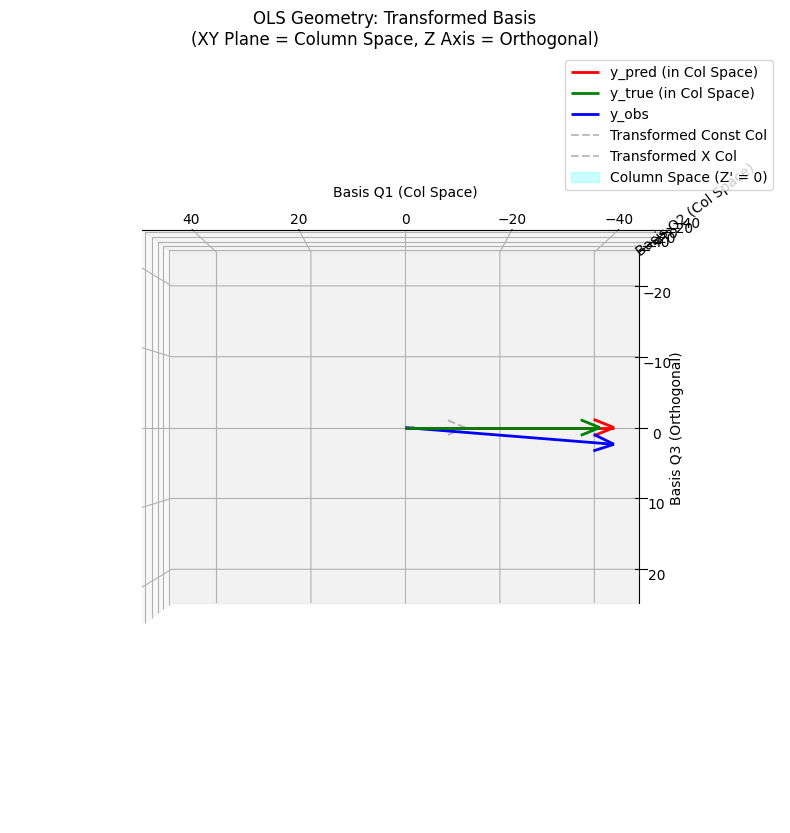

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define True Beta (Intercept=5, Slope=2.5)
beta_true = np.array([5, 2.5])

# --- 1. Prepare Vectors in Standard Observation Space ---
# v_manual: Predicted y (X @ beta_hat)
v_manual = y_pred.values.flatten()
# v_true: True y (X @ beta_true)
v_true = (X_const @ beta_true).values.flatten()
# v_obs: Observed y
v_obs = y

# Original Basis Vectors of Column Space
col1 = X_const['const'].values
col2 = X_const['X'].values

# --- 2. Change of Basis Logic ---
# Perform QR decomposition to get an orthonormal basis aligned with the Column Space
# Q columns 0 and 1 span the Column Space. Q column 2 is orthogonal to it.
Q, R = np.linalg.qr(X_const, mode='complete')

# Transformation: v_new = Q.T @ v_old
def transform_to_new_basis(v):
    return Q.T @ v

# Transform all vectors
v_manual_new = transform_to_new_basis(v_manual)
v_true_new = transform_to_new_basis(v_true)
v_obs_new = transform_to_new_basis(v_obs)
col1_new = transform_to_new_basis(col1)
col2_new = transform_to_new_basis(col2)

# --- 3. Plotting in the New Basis ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot Vectors
# Note: We plot (x, y, z) components from the transformed vectors
ax.quiver(0, 0, 0, v_manual_new[0], v_manual_new[1], v_manual_new[2], color='red', label='y_pred (in Col Space)', arrow_length_ratio=0.1, linewidth=2)
ax.quiver(0, 0, 0, v_true_new[0], v_true_new[1], v_true_new[2], color='green', label='y_true (in Col Space)', arrow_length_ratio=0.1, linewidth=2)
ax.quiver(0, 0, 0, v_obs_new[0], v_obs_new[1], v_obs_new[2], color='blue', label='y_obs', arrow_length_ratio=0.1, linewidth=2)

# Plot Transformed original basis vectors (const and X)
ax.quiver(0, 0, 0, col1_new[0], col1_new[1], col1_new[2], color='gray', linestyle='--', alpha=0.5, label='Transformed Const Col')
ax.quiver(0, 0, 0, col2_new[0], col2_new[1], col2_new[2], color='gray', linestyle='--', alpha=0.5, label='Transformed X Col')

# --- Visualize the 2D Column Space Plane ---
# Re-create the meshgrid of coefficients
b0_range = np.linspace(0, 6, 10)
b1_range = np.linspace(0, 4, 10)
B0, B1 = np.meshgrid(b0_range, b1_range)

# Calculate plane points in the NEW basis
# Point_new = B0 * col1_new + B1 * col2_new
Plane_X = B0 * col1_new[0] + B1 * col2_new[0]
Plane_Y = B0 * col1_new[1] + B1 * col2_new[1]
Plane_Z = B0 * col1_new[2] + B1 * col2_new[2] # This should be effectively 0

# Plot the surface
surf = ax.plot_surface(Plane_X, Plane_Y, Plane_Z, alpha=0.2, color='cyan')
import matplotlib.patches as mpatches
plane_proxy = mpatches.Patch(color='cyan', alpha=0.2, label='Column Space (Z\' = 0)')

# Set limits
limit = max(np.max(np.abs(v_manual_new)), np.max(np.abs(v_obs_new))) * 1.2
ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])
ax.set_zlim([-limit/2, limit/2])

# Labels
ax.set_xlabel('Basis Q1 (Col Space)')
ax.set_ylabel('Basis Q2 (Col Space)')
ax.set_zlabel('Basis Q3 (Orthogonal)')
ax.set_title('OLS Geometry: Transformed Basis\n(XY Plane = Column Space, Z Axis = Orthogonal)')

# Legend
handles, labels = ax.get_legend_handles_labels()
handles.append(plane_proxy)
ax.legend(handles=handles)

# View angle
ax.view_init(elev=180, azim=90)

plt.show()

In [11]:
# Define predictors (add constant for intercept)
X_const = sm.add_constant(df['X'])

# Manual OLS regression: (X^T * X)^(-1) * X^T * y
# Calculating beta using the normal equation
beta_manual = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ df['y']

print("Manual Coefficients:")
print(beta_manual)
print("-" * 30)



Manual Coefficients:
0    1.06295
1    3.02416
dtype: float64
------------------------------


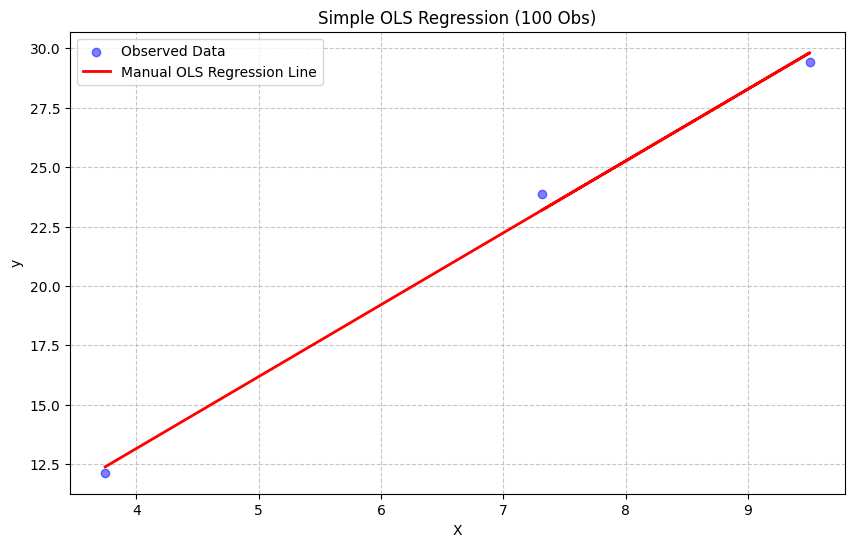

In [12]:
# Calculate predictions using manual beta
y_pred = X_const @ beta_manual.values.reshape(2, -1)
# Plot the data and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['X'], df['y'], color='blue', alpha=0.5, label='Observed Data')
plt.plot(df['X'], y_pred, color='red', linewidth=2, label='Manual OLS Regression Line')

plt.title('Simple OLS Regression (100 Obs)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()